# Python for Data Analysis

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

In [3]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [4]:
fund_master.shape

(40, 15)

In [5]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [6]:
fund_master.dtypes

amfi_code               int64
fund_house                str
scheme_name               str
category                  str
sub_category              str
plan                      str
launch_date               str
benchmark                 str
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumpsum_amount      int64
fund_manager              str
risk_category             str
sebi_category_code        str
dtype: object

In [7]:
fund_master.isnull().sum()

amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

In [8]:
fund_master.duplicated().sum()

np.int64(0)

In [9]:
fund_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     str    
 13  risk_category       40 non-null     str    
 14  sebi_category_code  40 non-null     str    
dtypes: float64(2), int64(3), str(10)
memory usage: 4.8 KB


In [10]:
fund_master.describe()

,amfi_code,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount
count,40.000000,40.000000,40.000000,40.0,40.000000
mean,120247.000000,1.237000,0.812500,500.0,1277.500000
std,14534.998667,0.386584,0.387091,0.0,1082.847031
min,100016.000000,0.550000,0.000000,500.0,100.000000
25%,118632.750000,0.787500,1.000000,500.0,1000.000000
50%,119551.500000,1.425000,1.000000,500.0,1000.000000
75%,120842.250000,1.540000,1.000000,500.0,1000.000000
max,149324.000000,1.640000,1.000000,500.0,5000.000000


In [11]:
fund_master.describe(include="object")

C:\Users\HP\AppData\Local\Temp\ipykernel_1520\1635377793.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  fund_master.describe(include="object")


,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,fund_manager,risk_category,sebi_category_code
count,40,40,40,40,40,40,40,40,40,40
unique,10,40,2,12,2,34,10,29,5,9
top,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2013-01-01,NIFTY 100 TRI,Sohini Andani,Moderate,EC01
freq,5,1,34,14,32,7,14,2,16,14


In [12]:
print("Total Mutual Fund Schemes:", len(fund_master))

Total Mutual Fund Schemes: 40


In [13]:
print("Total Fund Houses:", fund_master["fund_house"].nunique())

Total Fund Houses: 10


In [14]:
fund_master["category"].value_counts()

category
Equity    34
Debt       6
Name: count, dtype: int64

In [15]:
fund_master["plan"].value_counts()

plan
Regular    32
Direct      8
Name: count, dtype: int64

In [16]:
fund_master["risk_category"].value_counts()

risk_category
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [17]:
fund_master["expense_ratio_pct"].mean()

np.float64(1.237)

In [18]:
fund_master["expense_ratio_pct"].max()

np.float64(1.64)

In [19]:
fund_master["fund_house"].value_counts().head()

fund_house
SBI Mutual Fund        5
HDFC Mutual Fund       5
ICICI Prudential MF    5
Nippon India MF        5
Kotak Mahindra MF      4
Name: count, dtype: int64

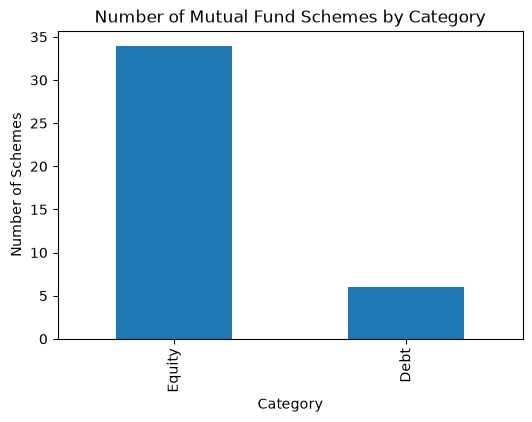

In [20]:
category_count = fund_master["category"].value_counts()

category_count.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Number of Mutual Fund Schemes by Category")
plt.xlabel("Category")
plt.ylabel("Number of Schemes")

plt.show()

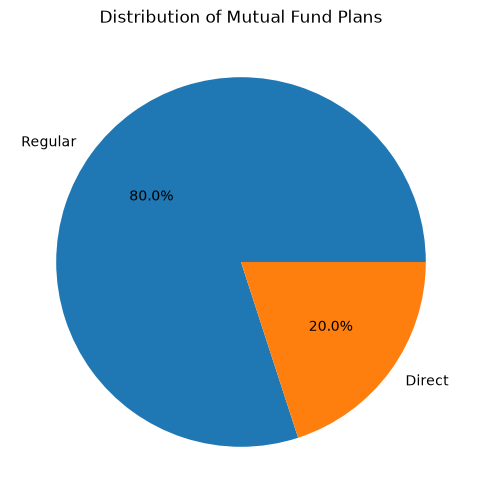

In [21]:
plan_count = fund_master["plan"].value_counts()

plan_count.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Distribution of Mutual Fund Plans")

plt.ylabel("")

plt.show()

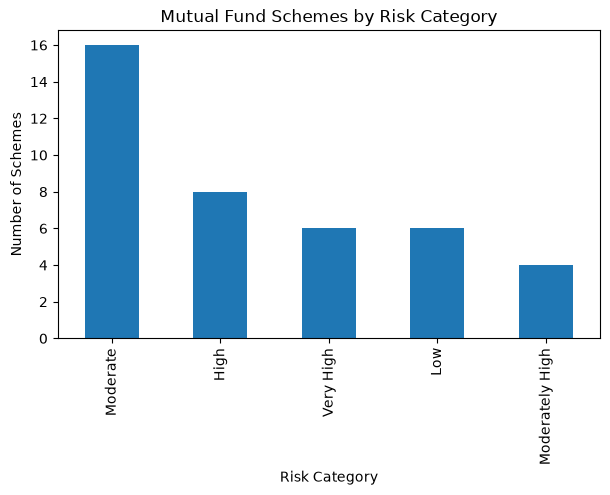

In [22]:
risk_count = fund_master["risk_category"].value_counts()

risk_count.plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Mutual Fund Schemes by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Number of Schemes")

plt.show()

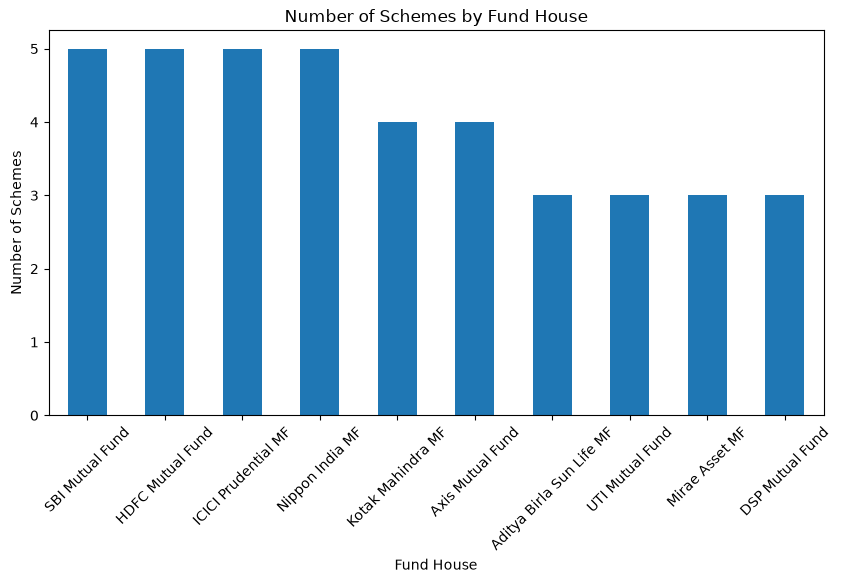

In [23]:
fund_house_count = fund_master["fund_house"].value_counts()

fund_house_count.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Number of Schemes by Fund House")
plt.xlabel("Fund House")
plt.ylabel("Number of Schemes")

plt.xticks(rotation=45)

plt.show()

## Data Cleaning & Exploratory Data Analysis (EDA)

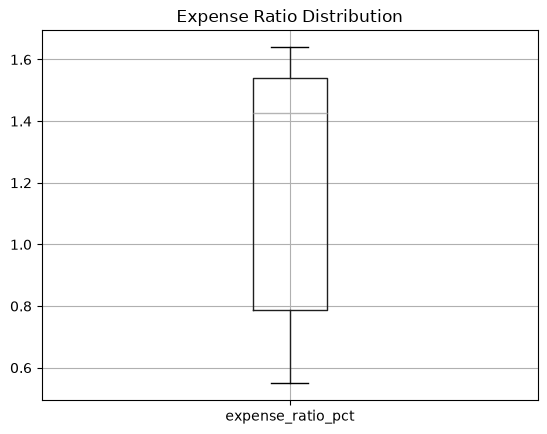

In [26]:
fund_master.boxplot(column="expense_ratio_pct")

plt.title("Expense Ratio Distribution")

plt.show()

In [27]:
numeric_columns = fund_master.select_dtypes(include=["int64", "float64"])

numeric_columns.corr()

,amfi_code,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount
amfi_code,1.000000,0.153835,0.227887,NaN,-0.116119
expense_ratio_pct,0.153835,1.000000,0.529036,NaN,-0.368232
exit_load_pct,0.227887,0.529036,1.000000,NaN,-0.551698
min_sip_amount,NaN,NaN,NaN,NaN,NaN
min_lumpsum_amount,-0.116119,-0.368232,-0.551698,NaN,1.000000


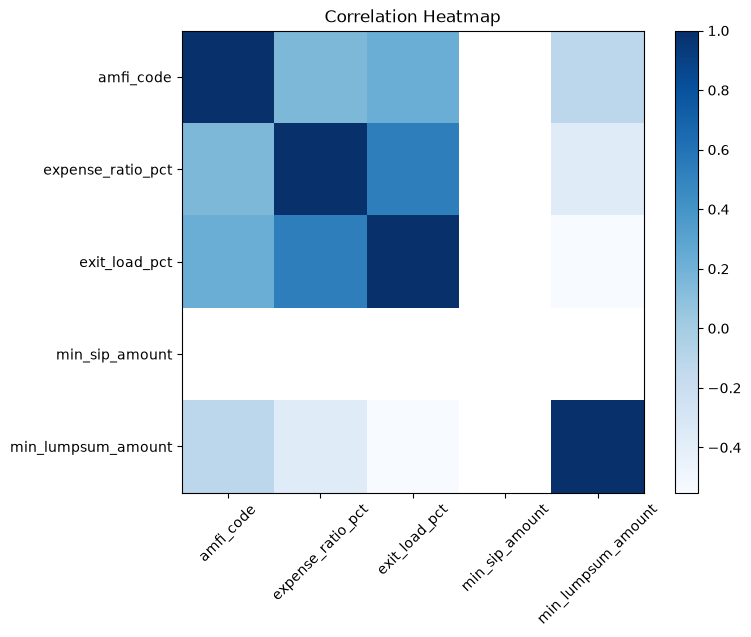

In [28]:
correlation = numeric_columns.corr()

plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="Blues")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.show()

## Business Insights

- The dataset contains information on 40 mutual fund schemes from 10 different fund houses.
- Equity schemes make up the majority of the available mutual funds.
- Moderate-risk schemes are the most common in the dataset.
- The average expense ratio is approximately 1.24%, while the highest expense ratio is 1.64%.
- No missing values or duplicate records were found, indicating good data quality.

# Statistics for Data Analysis

In [29]:
fund_master["expense_ratio_pct"].mean()

np.float64(1.237)

In [30]:
fund_master["expense_ratio_pct"].median()

np.float64(1.4249999999999998)

In [31]:
fund_master["expense_ratio_pct"].mode()

0    1.38
Name: expense_ratio_pct, dtype: float64

In [32]:
fund_master["expense_ratio_pct"].std()

np.float64(0.3865839876238791)

In [33]:
print("Minimum:", fund_master["expense_ratio_pct"].min())
print("Maximum:", fund_master["expense_ratio_pct"].max())

Minimum: 0.55
Maximum: 1.64


In [34]:
fund_master["expense_ratio_pct"].describe()

count    40.000000
mean      1.237000
std       0.386584
min       0.550000
25%       0.787500
50%       1.425000
75%       1.540000
max       1.640000
Name: expense_ratio_pct, dtype: float64

## Correlation

The correlation matrix was calculated during the EDA section. It helps identify relationships between the numerical variables in the dataset.

## Probability Basics

Probability represents the likelihood of an event occurring.

Example:
If 34 out of 40 schemes are Equity funds,

Probability of selecting an Equity scheme

= 34 / 40

= 0.85

= 85%

In [35]:
equity_count = (fund_master["category"] == "Equity").sum()

total = len(fund_master)

probability = equity_count / total

print("Probability of selecting an Equity fund:", probability)

Probability of selecting an Equity fund: 0.85


## Regression

Regression is a statistical technique used to understand the relationship between variables and to predict future values.

In mutual fund analytics, regression can be used to study how factors such as expense ratio, fund category, or market conditions influence fund performance.